<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [3]:
days = np.arange(1,121)

miles = (
    50
    + days * 0.8
    + 10 * np.sin(days/5)
    + np.random.normal(0,2,120)
)

data = pd.DataFrame({
    "Day": days,
    "Miles_Travelled": miles
})

# Save Dataset
data.to_csv("vehicle_miles.csv", index=False)

print(data.head())

   Day  Miles_Travelled
0    1        52.857400
1    2        53.096585
2    3        58.918334
3    4        60.787336
4    5        63.671604


In [4]:
data = pd.read_csv("vehicle_miles.csv")

print(data.head())

   Day  Miles_Travelled
0    1        52.857400
1    2        53.096585
2    3        58.918334
3    4        60.787336
4    5        63.671604


In [5]:
miles_data = data.iloc[:,1].values.reshape(-1,1)

# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(miles_data)

print(scaled_data[:5])

[[0.        ]
 [0.00265749]
 [0.06734053]
 [0.08810624]
 [0.12015215]]


In [6]:
def create_dataset(dataset, time_step=5):

    X, Y = [], []

    for i in range(len(dataset)-time_step-1):

        a = dataset[i:(i+time_step),0]

        X.append(a)

        Y.append(dataset[i + time_step,0])

    return np.array(X), np.array(Y)

# Create Sequences
time_step = 5

X, y = create_dataset(scaled_data, time_step)

In [7]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(time_step,1)
))

model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display Model Summary
model.summary()

(114, 5, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2020
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0255 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0047
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0030 
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028
Epoch 16/50
15/

In [9]:
predictions = model.predict(X)

# Convert Back to Original Scale
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y.reshape(-1,1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


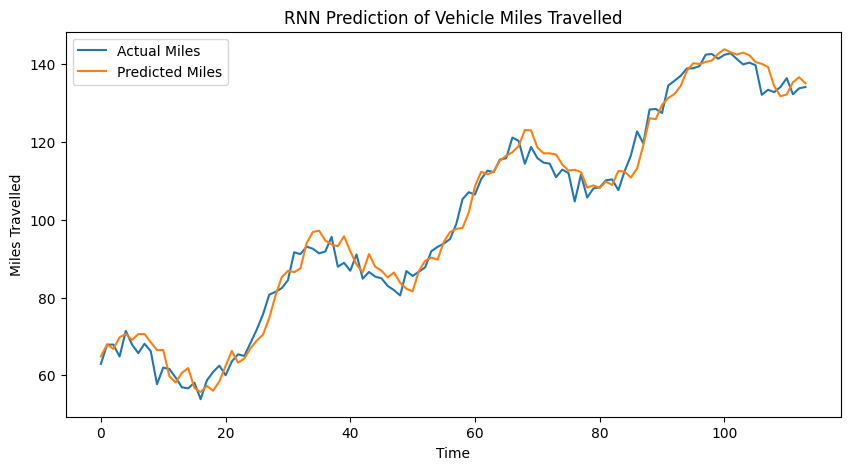

In [10]:
plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Miles")

plt.plot(predictions, label="Predicted Miles")

plt.xlabel("Time")

plt.ylabel("Miles Travelled")

plt.title("RNN Prediction of Vehicle Miles Travelled")

plt.legend()

plt.show()